文件用于数据分析、可视化和测试

In [14]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


用于数据分析

In [15]:
import sys
import os

# 找到项目的根目录（b.ipynb 的上一级目录）
project_root = os.path.abspath("../../")
sys.path.append(project_root)

In [16]:
import pandas as pd

In [17]:
file_path = r'E:/Stock/trade/data_center/storage/market_data/stock_daily/000004.SZ.parquet'

In [18]:
df = pd.read_parquet(file_path)
df

,open,high,low,close,volume,amount,code,adj_factor,limit_up,limit_down
datetime,,,,,,,,,,
2014-01-02,11.64,11.87,11.45,11.81,9714,11417555.0,000004.SZ,1.0,NaN,NaN
2014-01-03,11.70,11.97,11.68,11.80,27798,32882223.0,000004.SZ,1.0,12.40,11.22
2014-01-06,11.77,12.80,11.73,12.30,70466,87850516.0,000004.SZ,1.0,12.39,11.21
2014-01-07,12.00,12.33,11.81,12.23,29094,35085952.0,000004.SZ,1.0,12.92,11.69
2014-01-08,12.20,12.47,12.02,12.23,18272,22322956.0,000004.SZ,1.0,12.84,11.62
...,...,...,...,...,...,...,...,...,...,...
2025-12-02,12.43,12.59,11.86,11.99,65911,79681653.0,000004.SZ,1.0,12.98,11.74
2025-12-03,11.94,12.28,11.56,11.66,54945,64850222.0,000004.SZ,1.0,12.59,11.39
2025-12-04,11.73,11.84,11.36,11.42,32837,37703208.0,000004.SZ,1.0,12.24,11.08


In [19]:
# from pathlib import Path

# DATA_DIR = Path("E:/Stock/trade/data_center/storage//market_data/stock_daily/")

# def main():
#     records = []

#     files = sorted(DATA_DIR.glob("*.parquet"))
#     print(f"发现 parquet 文件数量: {len(files)}")

#     for fp in files:
#         try:
#             df = pd.read_parquet(fp)

#             # 如果 index 就是 datetime（你贴出来的就是这种形式），可以直接用：
#             if not isinstance(df.index, pd.DatetimeIndex):
#                 # 保险一点：如果不是 DatetimeIndex，就尝试把 'datetime' 列转成 index
#                 if "datetime" in df.columns:
#                     df["datetime"] = pd.to_datetime(df["datetime"])
#                     df = df.set_index("datetime")
#                 else:
#                     print(f"⚠️ {fp.name} 没有 DatetimeIndex 也没有 'datetime' 列，跳过")
#                     continue

#             # 按时间排序，确保第一行是最早，最后一行是最晚
#             df = df.sort_index()

#             start_dt = df.index[0]
#             end_dt = df.index[-1]
#             n_rows = len(df)

#             # code 可以从列里取，也可以从文件名解析
#             code_in_df = df["code"].iloc[0] if "code" in df.columns else fp.stem

#             records.append({
#                 "file": fp.name,
#                 "code": code_in_df,
#                 "start": start_dt,
#                 "end": end_dt,
#                 "rows": n_rows,
#             })

#         except Exception as e:
#             print(f"❌ 读取 {fp} 失败: {e}")
#             continue

#     if not records:
#         print("没有成功统计到任何文件")
#         return

#     summary = pd.DataFrame(records)
#     # 按代码排序，也可以按 start 排
#     summary = summary.sort_values(by=["code", "start"])

#     # 打印前几行看看
#     print("\n=== 每个标的的起止日期 & 行数（前 10 条） ===")
#     print(summary.head(10))

#     # 保存一份汇总表
#     out_file = DATA_DIR / "stock_daily_datetime_range_summary.csv"
#     summary.to_csv(out_file, index=False, encoding="utf-8-sig")
#     print(f"\n✅ 已保存汇总到: {out_file}")

#     # 整体最早/最晚日期
#     global_start = summary["start"].min()
#     global_end = summary["end"].max()
#     print(f"\n📅 整体最早日期: {global_start}")
#     print(f"📅 整体最晚日期: {global_end}")

# if __name__ == "__main__":
#     main()


In [20]:
# 导入必要的库
import os
import pandas as pd
from strategy_pool.selectors.policy.n_pattern_policy import NPatternSelector
import pandas_market_calendars as mcal

In [21]:
start_date="2025-01-01"
end_date="2025-02-15"
# 自动生成选股文件路径列表
POOL_DIR = r"E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound"
MARKET_DIR = r"E:/Stock/trade/data_center/storage//market_data/stock_daily/"

In [22]:

selection_files = [POOL_DIR+"\\"+f"{date.strftime('%Y%m%d')}.csv" for date in pd.date_range(start_date, end_date)]
# selection_files

In [23]:
# 获取上交所的交易日历
exchange = mcal.get_calendar('XSHG')  # 获取上交所的交易日历

# 获取交易日（工作日且非节假日）
trade_days = exchange.valid_days(pd.to_datetime(start_date), pd.to_datetime(end_date))

# 移除时区信息
trade_days = trade_days.tz_localize(None)
trade_days

DatetimeIndex(['2025-01-02', '2025-01-03', '2025-01-06', '2025-01-07',
               '2025-01-08', '2025-01-09', '2025-01-10', '2025-01-13',
               '2025-01-14', '2025-01-15', '2025-01-16', '2025-01-17',
               '2025-01-20', '2025-01-21', '2025-01-22', '2025-01-23',
               '2025-01-24', '2025-01-27', '2025-02-05', '2025-02-06',
               '2025-02-07', '2025-02-10', '2025-02-11', '2025-02-12',
               '2025-02-13', '2025-02-14'],
              dtype='datetime64[ns]', freq=None)

In [24]:
# 确保选股文件存在，如果不存在则进行选股操作
selector = NPatternSelector()  # 实例化选股类
for selection_file in selection_files:
    # 获取文件对应的日期
    date = selection_file.split('\\')[-1].split('.')[0]  # 提取日期
    current_date = pd.to_datetime(date)

    # 判断是否是交易日
    if current_date in trade_days:
        if not os.path.exists(selection_file):
            print(f"文件 {selection_file} 不存在，进行选股操作...")
            selector.run(date=date, save=True)
        else:
            print(f"文件 {selection_file} 已存在，跳过选股操作")
    else:
        print(f"{current_date.date()} 不是交易日，跳过选股操作")

2025-01-01 不是交易日，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250102.csv 已存在，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250103.csv 已存在，跳过选股操作
2025-01-04 不是交易日，跳过选股操作
2025-01-05 不是交易日，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250106.csv 已存在，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250107.csv 已存在，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250108.csv 已存在，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250109.csv 已存在，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250110.csv 已存在，跳过选股操作
2025-01-11 不是交易日，跳过选股操作
2025-01-12 不是交易日，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250113.csv 已存在，跳过选股操作
文件 E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\20250114.csv 已存在，跳过选股操作
文件 E:\S

✅ 统计结果已保存: E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\analysis\stats.csv
📈 图表已保存：E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\analysis\daily_counts.png
            count
date             
2025-01-24     49
2025-01-27     69
2025-02-05     69
2025-02-06     95
2025-02-07    105
2025-02-10    122
2025-02-11    155
2025-02-12    131
2025-02-13    137
2025-02-14    108


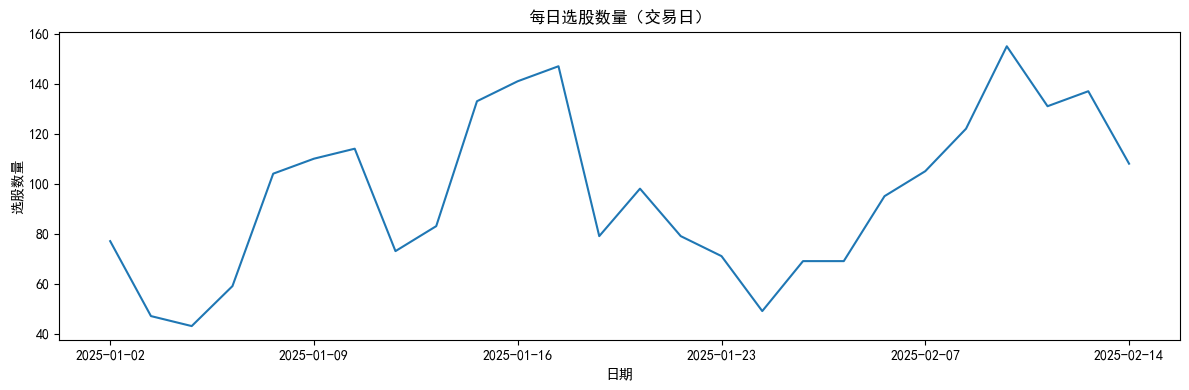

In [25]:
from strategy_pool.selectors.analyzer.base_analyzer import SelectorAnalyzerBase
from pathlib import Path

pool_dir = Path(r"E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound")
analysis_dir = pool_dir / "analysis"

analyzer = SelectorAnalyzerBase(
    start_date=start_date,
    end_date=end_date,
    analysis_output_dir=analysis_dir,
    code_col="code",
    date_col="select_time",
    exchange_calendar="XSHG"
)

df_selection, df_stats = analyzer.analyze_range(
    pool_dir=pool_dir,
    only_trade_days=True,   # ✅ 自动按交易日过滤/统计
    missing="skip",         # 缺文件先跳过（你也可以改成 "raise" 强制报错）
    plot=True
)

print(df_stats.tail(10))


In [26]:
from strategy_pool.selectors.analyzer.n_pattern_analyzer import NPatternAnalyzer
# ========= 初始化分析器 =========
analyzer = NPatternAnalyzer(
    start_date=start_date,
    end_date=end_date,
    pool_dir=POOL_DIR,
    market_data_dir=MARKET_DIR
)
#构造分析矩阵
analyzer.analyze_data_build( window_days= 10, past_days = 20)
# 每日选股数量（可选）
# analyzer.run_count_per_day(analyzer.df_selection, plot=True)

# 你要的散点套件（close极值）
# df_ext = analyzer.run_scatter_suite_close(days_forward=4)
# print(df_ext.head())

✅ df_selection loaded: rows=2498, patterns=['1板2调' '1板3调' '1板1调']
✅ 明细已保存：E:\Stock\trade\strategy_pool\selectors\pool_storage\n_pattern_rebound\analysis\extrema_speed_analysis.csv


,code,select_time,Pattern,n_adjust,board_limit_to_select_close_adj_pct,avg_limit_to_close_adj_per,board_close_to_select_close_adj_pct,avg_close_to_close_adj_per,upper_shadow_T,lower_shadow_T,...,max_gain_ratio_close,min_gain_ratio_close,days_to_max_open,days_to_min_open,max_ret_pct_open,min_ret_pct_open,max_gain_ratio_open,min_gain_ratio_open,ret_t1o_t2c_pct,win_t1o_t2c
0,002949.SZ,2025-01-02,1板2调,2,-8.524241,-4.262120,-8.524241,-4.262120,0.006407,0.013978,...,1.427677,0.000000,6,3,0.351906,-5.689150,0.058651,-1.896383,-6.334311,0
1,600629.SH,2025-01-02,1板2调,2,-6.688963,-3.344482,-6.688963,-3.344482,0.020311,0.008363,...,2.295918,-3.061224,5,3,3.753027,-9.564165,0.750605,-3.188055,-10.895884,0
2,603126.SH,2025-01-02,1板2调,2,0.122249,0.061125,0.122249,0.061125,0.092796,0.018315,...,0.000000,-3.450135,1,7,0.000000,-27.784578,0.000000,-3.969225,-12.362301,0
3,603153.SH,2025-01-02,1板2调,2,0.982801,0.491400,0.982801,0.491400,0.070560,0.034550,...,0.000000,-1.483257,1,8,0.000000,-15.148515,0.000000,-1.893564,-11.584158,0
4,601226.SH,2025-01-02,1板3调,3,0.000000,0.000000,0.000000,0.000000,0.017884,0.023845,...,4.044118,-0.588235,5,8,13.333333,-2.962963,2.666667,-0.370370,10.814815,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,605599.SH,2025-02-14,1板3调,3,-3.607383,-1.202461,-3.607383,-1.202461,0.002611,0.005222,...,0.000000,-2.079723,2,4,1.679929,-1.414677,0.839965,-0.353669,-2.210433,0
2494,600172.SH,2025-02-14,1板2调,2,-2.008929,-1.004464,-2.008929,-1.004464,0.006834,0.004556,...,0.450450,-0.765766,5,3,2.764977,-2.534562,0.552995,-0.844854,-1.843318,0
2495,600516.SH,2025-02-14,1板2调,2,2.144250,1.072125,2.144250,1.072125,0.003817,0.022901,...,0.077519,-1.453488,6,3,0.192678,-3.468208,0.032113,-1.156069,-3.468208,0
2496,603612.SH,2025-02-14,1板2调,2,-3.877221,-1.938611,-3.877221,-1.938611,0.015686,0.008403,...,0.138810,-1.590006,10,3,3.567319,-2.186421,0.356732,-0.728807,-1.898734,0


In [27]:
analyzer.df_selection

,code_key,code,select_time,Close,board_date,board_limit,board_close,Pattern,n_adjust,board_limit_to_select_close_adj_pct,avg_limit_to_close_adj_per,board_close_to_select_close_adj_pct,avg_close_to_close_adj_per,Vol_Ratio,symbol,sector_code_name,industry_name,strategy_name,date
0,2949,002949.SZ,2025-01-02,17.17,2024-12-30,18.77,18.77,1板2调,2,-8.524241,-4.262120,-8.524241,-4.262120,0.78,华阳国际,工业,专业技术服务业,n_pattern_rebound,20250102
1,600629,600629.SH,2025-01-02,8.37,2024-12-30,8.97,8.97,1板2调,2,-6.688963,-3.344482,-6.688963,-3.344482,1.46,华建集团,工业,专业技术服务业,n_pattern_rebound,20250102
2,603126,603126.SH,2025-01-02,8.19,2024-12-30,8.18,8.18,1板2调,2,0.122249,0.061125,0.122249,0.061125,1.15,中材节能,工业,专业技术服务业,n_pattern_rebound,20250102
3,603153,603153.SH,2025-01-02,20.55,2024-12-30,20.35,20.35,1板2调,2,0.982801,0.491400,0.982801,0.491400,2.29,上海建科,信息技术,专业技术服务业,n_pattern_rebound,20250102
4,601226,601226.SH,2025-01-02,6.71,2024-12-27,6.71,6.71,1板3调,3,0.000000,0.000000,0.000000,0.000000,0.95,华电科工,工业,专业技术服务业,n_pattern_rebound,20250102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,605599,605599.SH,2025-02-14,11.49,2025-02-11,11.92,11.92,1板3调,3,-3.607383,-1.202461,-3.607383,-1.202461,0.69,菜百股份,原材料,零售业,n_pattern_rebound,20250214
2494,600172,600172.SH,2025-02-14,4.39,2025-02-12,4.48,4.48,1板2调,2,-2.008929,-1.004464,-2.008929,-1.004464,1.06,黄河旋风,原材料,非金属矿物制品业,n_pattern_rebound,20250214
2495,600516,600516.SH,2025-02-14,5.24,2025-02-12,5.13,5.13,1板2调,2,2.144250,1.072125,2.144250,1.072125,1.05,方大炭素,原材料,非金属矿物制品业,n_pattern_rebound,20250214
2496,603612,603612.SH,2025-02-14,17.85,2025-02-12,18.57,18.57,1板2调,2,-3.877221,-1.938611,-3.877221,-1.938611,0.46,索通发展,原材料,非金属矿物制品业,n_pattern_rebound,20250214
